Scaled feature matrix shape: (10000, 3)
k=2 | WCSS=22462.98 | silhouette=0.2480
k=3 | WCSS=17202.05 | silhouette=0.2731
k=4 | WCSS=13484.38 | silhouette=0.2958
k=5 | WCSS=10956.85 | silhouette=0.2997
k=6 | WCSS=9541.13 | silhouette=0.3155


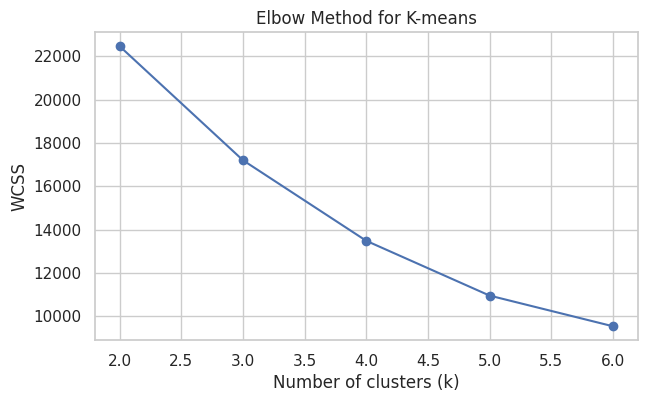

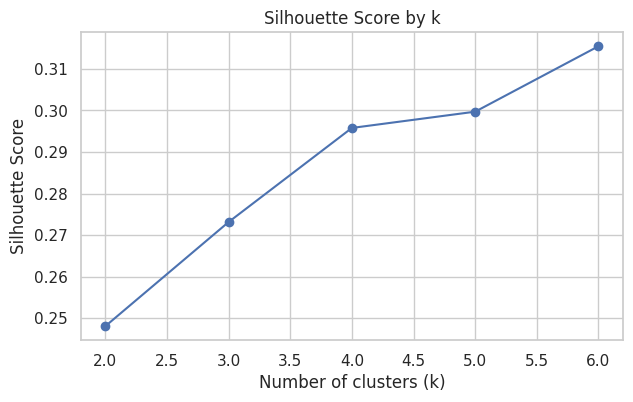

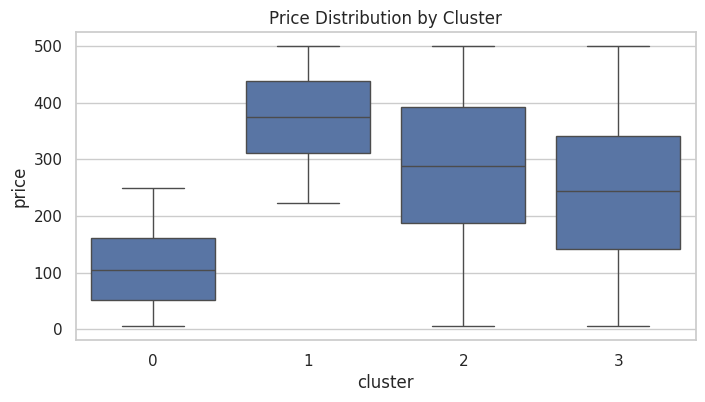

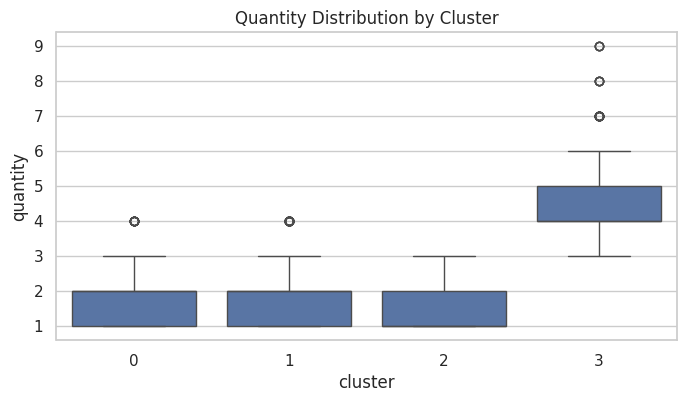

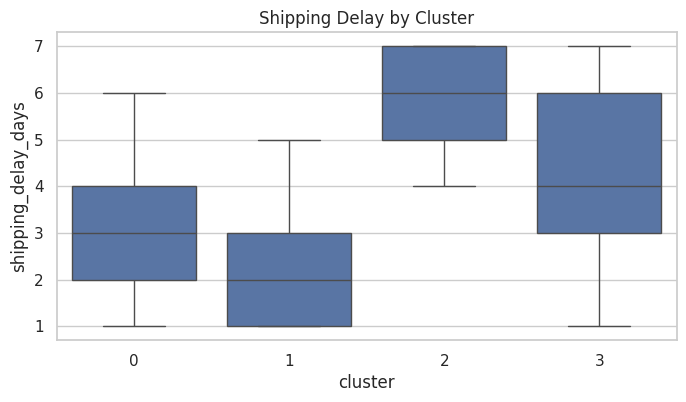

In [3]:
# 3. Unsupervised Clustering

#/home/pabodasanduni/Desktop/New Folder/Deep-Thinkers-ML-Project-main/project/ecommerce_orders_raw_data.csv

# Import data and plotting libraries.
#%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scaling and clustering tools.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use a clean plot style.
sns.set_theme(style="whitegrid")

# Load the shared dataset.
df = pd.read_csv("../project/ecommerce_orders_raw_data.csv")

# Parse the date columns.
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["shipping_date"] = pd.to_datetime(df["shipping_date"], errors="coerce")

# Create the shipping delay feature because it captures fulfillment behavior.
df["shipping_delay_days"] = (df["shipping_date"] - df["order_date"]).dt.days

# Keep a compact set of interpretable behavioral features for clustering.
cluster_df = df[["price", "quantity", "shipping_delay_days"]].copy()

# Show the first few rows.
cluster_df.head()

## Standardize the clustering variables

# Create the scaler.
scaler = StandardScaler()

# Fit the scaler and transform the data.
X_scaled = scaler.fit_transform(cluster_df)

# Print the transformed shape.
print("Scaled feature matrix shape:", X_scaled.shape)

## Choose k using the Elbow Method and Silhouette Score

# Create empty lists for the evaluation curves.
k_values = []
wcss_values = []
silhouette_values = []

# Test a range of candidate k values.
for k in range(2, 7):

    # Build the K-means model.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit and predict cluster labels.
    labels = kmeans.fit_predict(X_scaled)

    # Store the Within-Cluster Sum of Squares.
    k_values.append(k)
    wcss_values.append(kmeans.inertia_)

    # Store the silhouette score.
    silhouette_values.append(silhouette_score(X_scaled, labels, sample_size=400, random_state=42))

# Print the raw values so they are easy to discuss.
for k, wcss, sil in zip(k_values, wcss_values, silhouette_values):
    print(f"k={k} | WCSS={wcss:.2f} | silhouette={sil:.4f}")

# Plot the elbow curve.
plt.figure(figsize=(7, 4))
plt.plot(k_values, wcss_values, marker="o")
plt.title("Elbow Method for K-means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()

# Plot the silhouette scores.
plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# For this project, selecting **k = 4** is a reasonable business choice because it usually provides a visible elbow and keeps the final customer groups interpretable enough for marketing and operations teams.

# Set the final number of clusters.
final_k = 4

# Train the final K-means model.
final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)

# Fit and assign cluster labels.
df["cluster"] = final_kmeans.fit_predict(X_scaled)

# Display the distribution of cluster sizes.
df["cluster"].value_counts().sort_index()

# Compute easy-to-read cluster summaries.
cluster_summary = df.groupby("cluster")[["price", "quantity", "shipping_delay_days"]].mean().round(2)

# Add size information too.
cluster_summary["cluster_size"] = df["cluster"].value_counts().sort_index().values

# Display the centroid-style summary.
cluster_summary

## Example business interpretation template

#

# These cluster descriptions can support targeted campaigns, promotions, pricing strategy, and inventory planning.

# Visualize price by cluster.
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="cluster", y="price")
plt.title("Price Distribution by Cluster")
plt.show()

# Visualize quantity by cluster.
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="cluster", y="quantity")
plt.title("Quantity Distribution by Cluster")
plt.show()

# Visualize shipping delay by cluster.
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="cluster", y="shipping_delay_days")
plt.title("Shipping Delay by Cluster")
plt.show()